# LoVoCCS morphology: Hot ICM, BCG, red sequence, and WL mass **centroids**

This section of the project investigates the separation between major non-gaseous components of LoVoCCS galaxy clusters and the hot, X-ray emitting, intra-cluster medium. 

<span style="color:red">Bit more context</span>

## Main takeaways 

In summary:

* <span style="color:red">We investigate...</span>

## Import Statements

In [50]:
import pandas as pd
pd.set_option('display.max_columns', 500)
import numpy as np
from matplotlib import pyplot as plt
import os
from astropy.units import Quantity

# This adds the directory above to the path, allowing me to import the common functions that I've written in
#  common.py - this just saves me repeating boring code and makes sure its all consistent
import sys
sys.path.insert(0, '../')
from common import lovoccs_cosmo, haversine

# We could just re-implement this, but it is already there in XGA
from xga.sourcetools.misc import ang_to_rad

%matplotlib inline

## Useful values

Here we set up any values that are useful to several parts of the analysis in this notebook, and that we might wish to change in the future:

In [ ]:
# ALIGN_CONF_LEVEL = 95.4

## Output paths

Paths to save comparison figures and any output results files - defined here to avoid repetition and make the code easier to read: 

In [3]:
sep_fig_path = "../../outputs/figures/positions_and_morphology/coordinate_offsets/"
os.makedirs(sep_fig_path, exist_ok=True)

sep_res_path = "../../outputs/result_files/positions_and_morphology/"
os.makedirs(sep_res_path, exist_ok=True)

## Cosmological model

We employ the same cosmological model utilized in the LoVoCCS-I & II analyses (Fu et al. [2022](https://ui.adsabs.harvard.edu/abs/2022ApJ...933...84F/abstract), [2024](https://ui.adsabs.harvard.edu/abs/2024ApJ...974...69F/abstract)):

In [51]:
lovoccs_cosmo

LambdaCDM(name=None, H0=<Quantity 71. km / (Mpc s)>, Om0=0.2648, Ode0=0.7352, Tcmb0=<Quantity 0. K>, Neff=3.04, m_nu=None, Ob0=0.0448)

## Loading data files

Important considerations for this dataset:

* Some clusters selected for LoVoCCS have been identified as multiple blended systems in the course of the X-LoVoCCS project - other LoVoCCS works may only have entries/have made measurements for the overall system.
* Not all LoVoCCS-II galaxy clusters have XMM data available - as such we will not yet have measured X-ray centroids for them.

### X-LoVoCCS-I base sample

In [4]:
xlovoccs_base = pd.read_csv("../../sample_files/X-LoVoCCSI.csv")
xlovoccs_base.insert(0, 'name', xlovoccs_base['LoVoCCSID'].apply(lambda x: "LoVoCCS-" + str(x)))
xlovoccs_base.head(6)

,name,LoVoCCSID,parent_LoVoCCSID,Name,start_ra,start_dec,MCXC_Redshift,MCXC_R500,MCXC_RA,MCXC_DEC,manual_xray_ra,manual_xray_dec,MCXC_Lx500_0.1_2.4
0,LoVoCCS-1,1,1,A2029,227.734300,5.745471,0.0766,1.3344,227.73000,5.720000,227.734300,5.745471,8.726709e+44
1,LoVoCCS-2,2,2,A401,44.740000,13.580000,0.0739,1.2421,44.74000,13.580000,NaN,NaN,6.088643e+44
2,LoVoCCS-4A,4A,4,A85North,10.458750,-9.301944,0.0555,1.2103,10.45875,-9.301944,NaN,NaN,5.100085e+44
3,LoVoCCS-4B,4B,4,A85South,10.451487,-9.460007,0.0555,1.2103,10.45875,-9.301944,10.451487,-9.460007,5.100085e+44
4,LoVoCCS-5,5,5,A3667,303.157313,-56.845978,0.0556,1.1990,303.13000,-56.830000,303.157313,-56.845978,4.871933e+44
5,LoVoCCS-7,7,7,A3827,330.480000,-59.950000,0.0980,1.1367,330.48000,-59.950000,NaN,NaN,4.204419e+44


### X-LoVoCCS-I ICM centroid positions

This contains the centroid positions of the hot intra-cluster medium measured as part of this work:

In [6]:
xlovoccs_centroid = pd.read_csv("../../outputs/result_files/positions_and_morphology/xmm_500kpc_centroid_posang.csv")
xlovoccs_centroid.head(6)

,name,cent_ra,cent_ra-,cent_ra+,cent_dec,cent_dec-,cent_dec+,position_angle,position_angle-,position_angle+,ax_ratio,ax_ratio-,ax_ratio+
0,LoVoCCS-1,227.73324,0.00002,0.00002,5.74338,0.00003,0.00003,-73.0512,0.2030,0.2157,0.9202,0.0011,0.0012
1,LoVoCCS-2,44.73661,0.00017,0.00015,13.57730,0.00018,0.00016,23.7327,4.3632,3.8393,0.9746,0.0049,0.0043
2,LoVoCCS-4A,10.46006,0.00003,0.00004,-9.30457,0.00004,0.00004,67.2727,0.2179,0.1952,0.8910,0.0009,0.0010
3,LoVoCCS-4B,10.46330,0.00018,0.00016,-9.43280,0.00024,0.00029,-71.9520,0.9161,1.0538,0.9176,0.0047,0.0038
4,LoVoCCS-5,303.14189,0.00014,0.00015,-56.83829,0.00009,0.00007,40.0924,0.2190,0.2355,0.8262,0.0011,0.0012
5,LoVoCCS-7,330.47766,0.00011,0.00024,-59.94796,0.00011,0.00011,-78.3924,0.9435,0.8295,0.9519,0.0032,0.0037


### X-LoVoCCS-I ICM peak positions

This contains the coordinates of the X-ray peak positions we have measured for our X-LoVoCCS clusters:

In [8]:
xlovoccs_peak = pd.read_csv("../../outputs/result_files/positions_and_morphology/xmm_peak_coords.csv")
xlovoccs_peak.head(6)

,name,peak_ra,peak_dec
0,LoVoCCS-1,227.733253,5.745184
1,LoVoCCS-2,44.750675,13.594567
2,LoVoCCS-4,10.460369,-9.303375
3,LoVoCCS-5,303.100675,-56.851435
4,LoVoCCS-7,330.466217,-59.948751
5,LoVoCCS-9,67.812127,-61.453695


The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


### LoVoCCS-II BCG, red sequence, and mass distribution angles

**<span style="color:red">THIS WILL BE REPLACED ONCE THE LOVOCCS-II TABLE HAS A MORE PERMANENT HOME</span>**

Here we load a results file from another LoVoCCS work ([Fu et al. 2024](https://ui.adsabs.harvard.edu/abs/2024ApJ...974...69F/abstract)) which contains the positions of the BCGs, and centroid positions of the red-sequence and overall mass (represented by 2D weak-lensing) distributions.

In cases with multiple X-LoVoCCS-identified sub-clusters, we assign the red-sequence/weak-lensing mass position angle to the 'main' X-ray counterpart.

In [7]:
lovoccsII_morph = pd.read_csv("../../noupload_biaxiality_table.csv")
lovoccsII_morph.head(6)

,parent_LoVoCCSID,cluster,redshift_target,BCG_ra,BCG_dec,mass_map_ra,mass_map_dec,RS_map_ra,RS_map_dec,BCG_angle,mass_map_angle_05,mass_map_angle_10,mass_map_angle_20,RS_map_angle_05,RS_map_angle_10,RS_map_angle_20,cluster_type
0,1,A2029,0.0773,227.733771,5.744819,227.731704,5.775644,227.742692,5.770095,-62.61,84.602196,83.570516,-69.689253,-74.378012,-74.170775,-84.280216,a
1,2,A401,0.0743,44.740801,13.582686,44.741462,13.582399,44.742694,13.579045,-63.16,-6.824412,0.640114,-24.654011,-61.347490,-47.585406,-58.138832,a
2,4,A85,0.0556,10.460319,-9.303484,10.446739,-9.332133,10.405090,-9.312744,58.59,-70.095509,-84.031952,-40.610942,84.708468,72.220682,74.508138,b
3,5,A3667,0.0552,303.113931,-56.826788,303.135914,-56.845641,303.150738,-56.836339,44.27,-68.929259,79.595996,-84.325048,38.482847,44.175107,48.139765,a
4,7,A3827,0.0972,330.469621,-59.946597,330.458667,-59.942374,330.481129,-59.937518,72.40,78.181991,68.843089,56.923349,72.853008,64.101562,83.362138,a
5,9,A3266,0.0577,67.805321,-61.453344,67.799351,-61.432924,67.823175,-61.445007,-9.76,-74.274322,80.479806,86.423098,-25.382462,-24.227173,-43.988502,a


### Combining tables

In [10]:
xlovoccs_samp = pd.merge(xlovoccs_base, xlovoccs_centroid, left_on='name', right_on='name', how='outer')
xlovoccs_samp = pd.merge(xlovoccs_samp, xlovoccs_peak, left_on='name', right_on='name', how='outer')
xlovoccs_samp = pd.merge(xlovoccs_samp, lovoccsII_morph, left_on='parent_LoVoCCSID', right_on='parent_LoVoCCSID', how='inner')
xlovoccs_samp = xlovoccs_samp.sort_values('parent_LoVoCCSID').reset_index(drop=True)
xlovoccs_samp.head(6)

,name,LoVoCCSID,parent_LoVoCCSID,Name,start_ra,start_dec,MCXC_Redshift,MCXC_R500,MCXC_RA,MCXC_DEC,manual_xray_ra,manual_xray_dec,MCXC_Lx500_0.1_2.4,cent_ra,cent_ra-,cent_ra+,cent_dec,cent_dec-,cent_dec+,position_angle,position_angle-,position_angle+,ax_ratio,ax_ratio-,ax_ratio+,peak_ra,peak_dec,cluster,redshift_target,BCG_ra,BCG_dec,mass_map_ra,mass_map_dec,RS_map_ra,RS_map_dec,BCG_angle,mass_map_angle_05,mass_map_angle_10,mass_map_angle_20,RS_map_angle_05,RS_map_angle_10,RS_map_angle_20,cluster_type
0,LoVoCCS-1,1,1.0,A2029,227.734300,5.745471,0.0766,1.3344,227.73000,5.720000,227.734300,5.745471,8.726709e+44,227.73324,0.00002,0.00002,5.74338,0.00003,0.00003,-73.0512,0.2030,0.2157,0.9202,0.0011,0.0012,227.733253,5.745184,A2029,0.0773,227.733771,5.744819,227.731704,5.775644,227.742692,5.770095,-62.61,84.602196,83.570516,-69.689253,-74.378012,-74.170775,-84.280216,a
1,LoVoCCS-2,2,2.0,A401,44.740000,13.580000,0.0739,1.2421,44.74000,13.580000,NaN,NaN,6.088643e+44,44.73661,0.00017,0.00015,13.57730,0.00018,0.00016,23.7327,4.3632,3.8393,0.9746,0.0049,0.0043,44.750675,13.594567,A401,0.0743,44.740801,13.582686,44.741462,13.582399,44.742694,13.579045,-63.16,-6.824412,0.640114,-24.654011,-61.347490,-47.585406,-58.138832,a
2,LoVoCCS-4B,4B,4.0,A85South,10.451487,-9.460007,0.0555,1.2103,10.45875,-9.301944,10.451487,-9.460007,5.100085e+44,10.46330,0.00018,0.00016,-9.43280,0.00024,0.00029,-71.9520,0.9161,1.0538,0.9176,0.0047,0.0038,NaN,NaN,A85,0.0556,10.460319,-9.303484,10.446739,-9.332133,10.405090,-9.312744,58.59,-70.095509,-84.031952,-40.610942,84.708468,72.220682,74.508138,b
3,LoVoCCS-4A,4A,4.0,A85North,10.458750,-9.301944,0.0555,1.2103,10.45875,-9.301944,NaN,NaN,5.100085e+44,10.46006,0.00003,0.00004,-9.30457,0.00004,0.00004,67.2727,0.2179,0.1952,0.8910,0.0009,0.0010,NaN,NaN,A85,0.0556,10.460319,-9.303484,10.446739,-9.332133,10.405090,-9.312744,58.59,-70.095509,-84.031952,-40.610942,84.708468,72.220682,74.508138,b
4,LoVoCCS-5,5,5.0,A3667,303.157313,-56.845978,0.0556,1.1990,303.13000,-56.830000,303.157313,-56.845978,4.871933e+44,303.14189,0.00014,0.00015,-56.83829,0.00009,0.00007,40.0924,0.2190,0.2355,0.8262,0.0011,0.0012,303.100675,-56.851435,A3667,0.0552,303.113931,-56.826788,303.135914,-56.845641,303.150738,-56.836339,44.27,-68.929259,79.595996,-84.325048,38.482847,44.175107,48.139765,a
5,LoVoCCS-7,7,7.0,A3827,330.480000,-59.950000,0.0980,1.1367,330.48000,-59.950000,NaN,NaN,4.204419e+44,330.47766,0.00011,0.00024,-59.94796,0.00011,0.00011,-78.3924,0.9435,0.8295,0.9519,0.0032,0.0037,330.466217,-59.948751,A3827,0.0972,330.469621,-59.946597,330.458667,-59.942374,330.481129,-59.937518,72.40,78.181991,68.843089,56.923349,72.853008,64.101562,83.362138,a


### Reading out hot ICM central positions

We have two definitions of galaxy cluster position extracted from our X-ray data, the centroids of the surface brightness distribution, and the position of the peak in X-ray brightness. Both definitions may act as comparisons for LoVoCCS-II positions in the course of this notebook, so we read them out of the dataframe:

In [35]:
# Measured ICM centroid coordinates
icm_cent = Quantity(xlovoccs_samp[['cent_ra', 'cent_dec']].values, 'deg')
# And uncertainties on said coordinates
icm_cent_ra_err = Quantity(xlovoccs_samp[['cent_ra-', 'cent_ra+']].values, 'deg')
icm_cent_dec_err = Quantity(xlovoccs_samp[['cent_dec-', 'cent_dec+']].values, 'deg')

# The X-ray peak coordinates we measured
icm_peak = Quantity(xlovoccs_samp[['peak_ra', 'peak_dec']].values)

## Reading out LoVoCCS-II positions

To make things neater, we also read out the various central positions of LoVoCCS clusters into their own variables:

In [72]:
# These are all self-explanatory really
bcg_cent = Quantity(xlovoccs_samp[['BCG_ra', 'BCG_dec']].values, 'deg')
red_seq_cent = Quantity(xlovoccs_samp[['RS_map_ra', 'RS_map_dec']].values, 'deg')
wlm_cent = Quantity(xlovoccs_samp[['mass_map_ra', 'mass_map_dec']].values, 'deg')

## Separation-from-ICM distributions

### Calculating $\Delta[C^{\rm{ICM}}_{x,y}-C^{\rm{...}}_{x,y}]$ distributions

<span style="color:teal">When we decide on fiducial redshifts for the LoVoCCS clusters, this might have to change.</span>

Here we calculate the angular separation between various optical-components of the LoVoCCS galaxy clusters, and the X-ray centroids; a cosmological model, which is the same across all LoVoCCS analyses (look near the top of the notebook), combined with the cluster redshifts converts the angular separations into proper distances:

In [73]:
delta_icm_bcg = haversine(icm_cent[:, 0], icm_cent[:, 1], bcg_cent[:, 0], bcg_cent[:, 1])
delta_icm_req_seq = haversine(icm_cent[:, 0], icm_cent[:, 1], red_seq_cent[:, 0], red_seq_cent[:, 1])
delta_icm_wlm = haversine(icm_cent[:, 0], icm_cent[:, 1], wlm_cent[:, 0], wlm_cent[:, 1])

# Now we must make sure that these angular separations are turned into a proper distance, so we can make 
#  like-for-like comparisons between different LoVoCCS systems
prop_delta_icm_bcg = ang_to_rad(delta_icm_bcg, xlovoccs_samp['MCXC_Redshift'].values, lovoccs_cosmo)
prop_delta_icm_red_seq = ang_to_rad(delta_icm_req_seq, xlovoccs_samp['MCXC_Redshift'].values, lovoccs_cosmo)
prop_delta_icm_wlm = ang_to_rad(delta_icm_wlm, xlovoccs_samp['MCXC_Redshift'].values, lovoccs_cosmo)

### Finding minimum and maximum separations

We will examine the full distributions, but in the meantime it might be instructive to look at the galaxy clusters with the smallest and largest distances between the centroids of their different components. To remove the effects of the Universe's expansion, we will use the 'proper distance' separations.

The largest separations may be the result of the X-LoVoCCS work splitting LoVoCCS clusters into multiple sub-clusters, but there being only a single, overall, centroid position from the LoVoCCS-II analysis. Names with A, B, or C at the end indicate that the LoVoCCS cluster has been split by X-LoVoCCS.

#### ICM-BCG

In [75]:
# Simply finding the index of the smallest proper separation entry, which we then use to find the
#  name of the cluster it corresponds to
icm_bcg_min_ind = np.nanargmin(prop_delta_icm_bcg)
icm_bcg_min_val = prop_delta_icm_bcg[icm_bcg_min_ind].round(4)
icm_bcg_min_name = xlovoccs_samp['name'].values[icm_bcg_min_ind]

# The same process but for the largest proper separation
icm_bcg_max_ind = np.nanargmax(prop_delta_icm_bcg)
icm_bcg_max_val = prop_delta_icm_bcg[icm_bcg_max_ind].round(4)
icm_bcg_max_name = xlovoccs_samp['name'].values[icm_bcg_max_ind]

print(icm_bcg_min_name, 'has the smallest proper separation between ICM and BCG centroids -', icm_bcg_min_val)
print(icm_bcg_max_name, 'has the largest proper separation between ICM and BCG centroids -', icm_bcg_max_val)

LoVoCCS-15 has the smallest proper separation between ICM and BCG centroids - 2.0534 kpc
LoVoCCS-66B has the largest proper separation between ICM and BCG centroids - 1076.4028 kpc


#### ICM-Red Sequence

In [76]:
# Simply finding the index of the smallest proper separation entry, which we then use to find the
#  name of the cluster it corresponds to
icm_red_seq_min_ind = np.nanargmin(prop_delta_icm_red_seq)
icm_red_seq_min_val = prop_delta_icm_red_seq[icm_red_seq_min_ind].round(4)
icm_red_seq_min_name = xlovoccs_samp['name'].values[icm_red_seq_min_ind]

# The same process but for the largest proper separation
icm_red_seq_max_ind = np.nanargmax(prop_delta_icm_red_seq)
icm_red_seq_max_val = prop_delta_icm_red_seq[icm_red_seq_max_ind].round(4)
icm_red_seq_max_name = xlovoccs_samp['name'].values[icm_red_seq_max_ind]

print(icm_red_seq_min_name, 'has the smallest proper separation between ICM and Red Sequence centroids -', icm_red_seq_min_val)
print(icm_red_seq_max_name, 'has the largest proper separation between ICM and Red Sequence centroids -', icm_red_seq_max_val)

LoVoCCS-80 has the smallest proper separation between ICM and Red Sequence centroids - 10.403 kpc
LoVoCCS-66B has the largest proper separation between ICM and Red Sequence centroids - 1018.8632 kpc


#### ICM-WLM

In [77]:
# Simply finding the index of the smallest proper separation entry, which we then use to find the
#  name of the cluster it corresponds to
icm_wlm_min_ind = np.nanargmin(prop_delta_icm_wlm)
icm_wlm_min_val = prop_delta_icm_wlm[icm_wlm_min_ind].round(4)
icm_wlm_min_name = xlovoccs_samp['name'].values[icm_wlm_min_ind]

# The same process but for the largest proper separation
icm_wlm_max_ind = np.nanargmax(prop_delta_icm_wlm)
icm_wlm_max_val = prop_delta_icm_wlm[icm_wlm_max_ind].round(4)
icm_wlm_max_name = xlovoccs_samp['name'].values[icm_wlm_max_ind]

print(icm_wlm_min_name, 'has the smallest proper separation between ICM and WLM centroids -', icm_wlm_min_val)
print(icm_wlm_max_name, 'has the largest proper separation between ICM and WLM centroids -', icm_wlm_max_val)

LoVoCCS-48A has the smallest proper separation between ICM and WLM centroids - 7.531 kpc
LoVoCCS-93A has the largest proper separation between ICM and WLM centroids - 1001.0738 kpc


### How do separations of different cluster components compare?

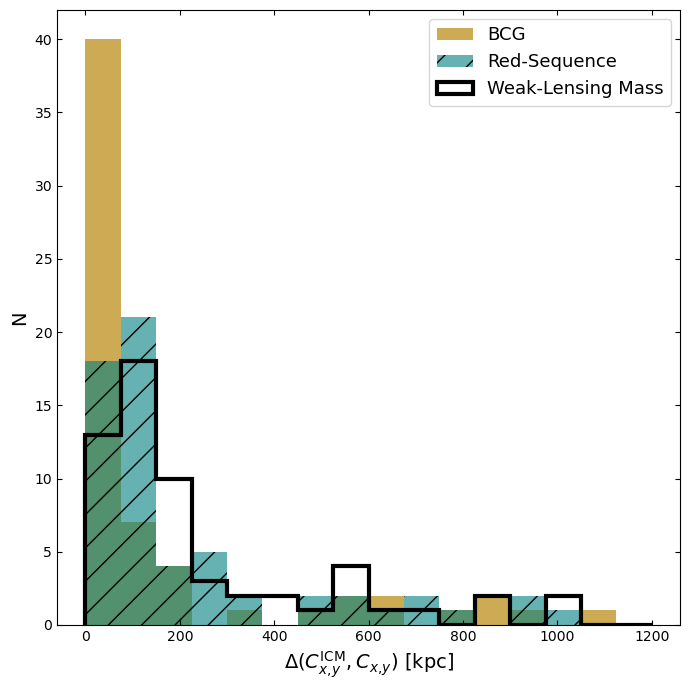

In [96]:
# Configures the histogram
step_size = 75
bins = np.arange(0, 1200+step_size, step_size)

# Makes the matplotlib figure
plt.figure(figsize=(7, 7))

plt.minorticks_off()
plt.tick_params(which='both', direction='in', top=True, right=True)

# BCG separation
plt.hist(prop_delta_icm_bcg.value, bins=bins, alpha=0.7, histtype='stepfilled', color="darkgoldenrod", 
         linewidth=3, label="BCG")
# RS separation
plt.hist(prop_delta_icm_red_seq.value, bins=bins, alpha=0.6, histtype='stepfilled', color="teal", 
         linewidth=3, label="Red-Sequence", hatch='/')
# Mass dist. separation
plt.hist(prop_delta_icm_wlm.value, bins=bins, alpha=1, histtype='step', color="black", 
         linewidth=3, label="Weak-Lensing Mass")

plt.ylabel('N', fontsize=14)
plt.xlabel(r'$\Delta(C^{\rm{ICM}}_{x,\!y}, C_{x,\!y})$ [kpc]', fontsize=14)

plt.legend(loc='best', fontsize=13)
plt.tight_layout()
plt.savefig(sep_fig_path + "delta_icm-bcg_rs_wlm_centroid_dist.pdf")
plt.show()

## 

#### Median and confidence limits of galaxy cluster component alignment with ICM

In [ ]:
# Median, lower, and upper confidence limits (specified at the top of the notebook) for ICM-BCG alignment
med_delta_icm_bcg = np.nanmedian(delta_icm_bcg).round(3)
low_delta_icm_bcg = np.nanpercentile(delta_icm_bcg, (50 - (ALIGN_CONF_LEVEL/2))).round(3)
upp_delta_icm_bcg = np.nanpercentile(delta_icm_bcg, (50 + (ALIGN_CONF_LEVEL/2))).round(3)
# Will also measure a sigma, just to have a single number to complement the confidence interval
std_delta_icm_bcg = np.nanstd(delta_icm_bcg).round(3)

# Median, lower, and upper confidence limits (specified at the top of the notebook) for ICM-RS alignment
med_delta_icm_rs500kpc = np.nanmedian(delta_icm_rs500kpc).round(3)
low_delta_icm_rs500kpc = np.nanpercentile(delta_icm_rs500kpc, (50 - (ALIGN_CONF_LEVEL/2))).round(3)
upp_delta_icm_rs500kpc = np.nanpercentile(delta_icm_rs500kpc, (50 + (ALIGN_CONF_LEVEL/2))).round(3)
std_delta_icm_rs500kpc = np.nanstd(delta_icm_rs500kpc).round(3)

# Median, lower, and upper confidence limits (specified at the top of the notebook) for ICM-WLM alignment
med_delta_icm_wlm500kpc = np.nanmedian(delta_icm_wlm500kpc).round(3)
low_delta_icm_wlm500kpc = np.nanpercentile(delta_icm_wlm500kpc, (50 - (ALIGN_CONF_LEVEL/2))).round(3)
upp_delta_icm_wlm500kpc = np.nanpercentile(delta_icm_wlm500kpc, (50 + (ALIGN_CONF_LEVEL/2))).round(3)
std_delta_icm_wlm500kpc = np.nanstd(delta_icm_wlm500kpc).round(3)

We'll store this in a results file as well:

In [ ]:
data = [[med_delta_icm_bcg, low_delta_icm_bcg, upp_delta_icm_bcg, std_delta_icm_bcg], 
        [med_delta_icm_rs500kpc, low_delta_icm_rs500kpc, upp_delta_icm_rs500kpc, std_delta_icm_rs500kpc],
        [med_delta_icm_wlm500kpc, low_delta_icm_wlm500kpc, upp_delta_icm_wlm500kpc, std_delta_icm_wlm500kpc]]

alignment_summ = pd.DataFrame(data, columns=['alignment', 'alignment_{}%conf_low'.format(ALIGN_CONF_LEVEL), 
                                             'alignment_{}%conf_upp'.format(ALIGN_CONF_LEVEL), 'alignment_stddev'])
# alignment_summ.to_csv(align_res_path + "icm_component_alignment.csv", index=False)
alignment_summ

### Absolute alignment distribution

We also condense our sample into a single 0-90 degree space by taking the absolute value of the difference in position angles:

In [ ]:
# Configures the histogram
step_size = 10
bins = np.arange(0, 90+step_size, step_size)

# Makes the matplotlib figure
plt.figure(figsize=(7, 7))

plt.minorticks_off()
plt.tick_params(which='both', direction='in', top=True, right=True)

# BCG alignment
plt.hist(np.abs(delta_icm_bcg), bins=bins, alpha=0.7, histtype='stepfilled', color="darkgoldenrod", 
         linewidth=3, label="BCG")
# RS alignment
plt.hist(np.abs(delta_icm_rs500kpc), bins=bins, alpha=0.6, histtype='stepfilled', color="teal", 
         linewidth=3, label="Red-Sequence", hatch='/')
# Mass dist. alignment
plt.hist(np.abs(delta_icm_wlm500kpc), bins=bins, alpha=1, histtype='step', color="black", 
         linewidth=3, label="Weak-Lensing Mass")

# Setting the lower x-axis limit to zero, because these are absolute deltas
plt.xlim(0)

plt.ylabel('N', fontsize=14)
plt.xlabel(r'$|\Delta(\theta_{\rm{ICM}}-\theta)|$ [deg]', fontsize=14)

plt.legend(loc='best', fontsize=13)
plt.tight_layout()

# plt.savefig(pa_fig_path + "absolute_delta_icm-bcg_rs_wlm_posang_dist.pdf")
plt.show()